In [ ]:
#  "mof_pdf_labels_using gpt4o only YN response 580.xlsx"
# "mof_pdf_labels_using gpt5 only YN response 478.xlsx"

In [10]:
# If needed:
# %pip install pandas openpyxl

import pandas as pd
import numpy as np
import re

# ========= File names (same folder as this notebook) =========
FULL_FILE = "Full.xlsx"
GPT5_FILE = "Full_gpt-5.xlsx"
GPT4MINI_FILE = "Full_gpt-4o-mini.xlsx"
GT_FILE = "mof_pdf_labels_using gpt5 only YN response 478.xlsx"
OPEN_SOURCE_FILE = "ground truth open access 500 around 278 download.xlsx"
OUTPUT_FILE = "Full_with_gpt5_gpt4omini.xlsx"

# Toggle this to True to restrict metrics to the ~278 open source rows
OPEN_SOURCE_ONLY = True
# Optional: limit to certain sheets by name, else None to scan all
OPEN_SOURCE_SHEETS = None  # e.g., ["Sheet1"]

# ========= Helpers =========
def normalize_colname(col):
    return "".join(ch for ch in str(col).strip().lower() if ch.isalnum())

def find_doi_column(df):
    for col in df.columns:
        if normalize_colname(col) == "doi":
            return col
    for c in ["DOI", "doi", "Doi"]:
        if c in df.columns:
            return c
    return df.columns[0]

def normalize_flag(val):
    if pd.isna(val):
        return pd.NA
    s = str(val).strip()
    if s == "":
        return pd.NA
    u = s.upper()
    if u in {"Y","YES","TRUE","T","1"}:
        return "Y"
    if u in {"N","NO","FALSE","F","0"}:
        return "N"
    return pd.NA

def find_flag_column(df, prefer_tokens):
    doi_col = find_doi_column(df)
    other_cols = [c for c in df.columns if c != doi_col]
    if not other_cols:
        raise KeyError("No candidate flag columns besides DOI.")
    norm_to_orig = {normalize_colname(c): c for c in other_cols}
    for token in prefer_tokens:
        tok_norm = normalize_colname(token)
        if tok_norm in norm_to_orig:
            return norm_to_orig[tok_norm]
    def yn_score(series):
        vals = series.dropna().astype(str).str.strip().str.upper()
        if len(vals) == 0:
            return 0.0
        return float(vals.isin(["Y","N","YES","NO","TRUE","FALSE","T","F","1","0"]).mean())
    scores = {c: yn_score(df[c]) for c in other_cols}
    return max(scores, key=scores.get)

def build_map(df, doi_col, flag_col):
    tmp = df[[doi_col, flag_col]].copy()
    tmp = tmp.dropna(subset=[doi_col])
    tmp[doi_col] = tmp[doi_col].astype(str).str.strip()  # Series-safe
    tmp = tmp.drop_duplicates(subset=[doi_col], keep="first")
    tmp[flag_col] = tmp[flag_col].map(normalize_flag)
    return dict(zip(tmp[doi_col], tmp[flag_col]))

def norm_doi(s):
    if pd.isna(s):
        return None
    st = str(s).strip()
    if not st:
        return None
    st = st.replace("\\", "/").replace("_", "/").lower()
    st = re.sub(r"^(https?://(dx\.)?doi\.org/|doi:)\s*", "", st)
    st = re.sub(r"\.pdf$", "", st)
    m = re.search(r"(10\.\d{4,9}/\S+)", st)
    if m:
        st = m.group(1)
    return st

def to_YN(val):
    if pd.isna(val): return None
    u = str(val).strip().upper()
    if u in {"Y","YES","TRUE","T","1"}: return "Y"
    if u in {"N","NO","FALSE","F","0"}: return "N"
    return None

def metrics_for(pred, truth):
    mask = pred.apply(to_YN).isin(["Y","N"])
    p = pred[mask].apply(to_YN)
    t = truth[mask].apply(to_YN)
    n = len(t)
    if n == 0:
        return {"n_eval": 0, "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan,
                "tp": 0, "fp": 0, "tn": 0, "fn": 0}
    tp = int(((p == "Y") & (t == "Y")).sum())
    tn = int(((p == "N") & (t == "N")).sum())
    fp = int(((p == "Y") & (t == "N")).sum())
    fn = int(((p == "N") & (t == "Y")).sum())
    acc = (tp + tn) / n
    prec = tp / (tp + fp) if (tp + fp) else np.nan
    rec = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = 2 * prec * rec / (prec + rec) if (prec is not np.nan and rec is not np.nan and (prec + rec)) else np.nan
    return {"n_eval": n, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
            "tp": tp, "fp": fp, "tn": tn, "fn": fn}

# Strictly pick only a column that is exactly 'donwloaded' or 'downloaded' after normalization
def find_exact_download_col(cols):
    norm = {normalize_colname(c): c for c in cols}
    if "donwloaded" in norm:
        return norm["donwloaded"]
    if "downloaded" in norm:
        return norm["downloaded"]
    return None

# Exact 1 matcher: either string "1" after strip or numeric 1 after coercion
def exact_one_mask(series):
    s = series.astype(str).str.strip()
    num = pd.to_numeric(s, errors="coerce")
    return s.eq("1") | num.eq(1)

def detect_doi_column_general(df):
    if "File" in df.columns:
        return "File"
    for c in df.columns:
        if normalize_colname(c) == "doi":
            return c
    # Heuristic DOI-like
    best_col, best_share = None, 0.0
    pat = re.compile(r"10\.\d{4,9}/\S+")
    for c in df.columns:
        vals = df[c].astype(str)
        share = vals.str.contains(pat).mean()
        if share > best_share:
            best_col, best_share = c, share
    return best_col if best_col is not None else df.columns[0]

def audit_open_source_file(xlsx_path, sheet_filter=None, force_col=None):
    """
    Read all sheets. Use ONLY the exact 'donwloaded' or 'downloaded' column.
    Keep rows where that column equals 1 exactly.
    Print per-sheet value_counts to help verify the expected ~278.
    Return (unique_doi_set, total_rows_flagged_one).
    """
    book = pd.read_excel(xlsx_path, sheet_name=None, dtype=object)
    doi_set = set()
    raw_rows = 0

    print("\nOpen source workbook sheets:", list(book.keys()))
    for sheet_name, df in book.items():
        if sheet_filter and sheet_name not in sheet_filter:
            continue

        dl_col = force_col if (force_col and force_col in df.columns) else find_exact_download_col(df.columns)
        if dl_col is None:
            print(f"[{sheet_name}] skipped: no 'donwloaded' or 'downloaded' column")
            continue

        vc = df[dl_col].astype(str).str.strip().value_counts(dropna=False)
        print(f"[{sheet_name}] download column '{dl_col}' value_counts:\n{vc}\n")

        mask = exact_one_mask(df[dl_col])
        cnt = int(mask.sum())
        raw_rows += cnt

        doi_col = detect_doi_column_general(df)
        dois_here = df[doi_col].apply(norm_doi)
        dois_here = dois_here[mask & dois_here.notna()]
        doi_set.update(dois_here.tolist())

    print(f"TOTAL flagged rows across sheets: {raw_rows}")
    print(f"TOTAL unique DOIs flagged: {len(doi_set)}")
    return doi_set, raw_rows

# ========= 1) Read main and model files, add model columns =========
print("Reading input files...")
full_df = pd.read_excel(FULL_FILE, dtype=object)
gpt5_df = pd.read_excel(GPT5_FILE, dtype=object)
gpt4mini_df = pd.read_excel(GPT4MINI_FILE, dtype=object)

full_doi_col = find_doi_column(full_df)
gpt5_doi_col = find_doi_column(gpt5_df)
gpt4mini_doi_col = find_doi_column(gpt4mini_df)

gpt5_flag_col = find_flag_column(gpt5_df, prefer_tokens=["gpt-5","gpt5","agent_yn","label","prediction"])
gpt4mini_flag_col = find_flag_column(gpt4mini_df, prefer_tokens=["gpt-4o-mini","gpt4omini","agent_yn","label","prediction"])

print(f"Detected DOI column in Full: {full_doi_col}")
print(f"Detected DOI/flag in gpt-5 file: {gpt5_doi_col} / {gpt5_flag_col}")
print(f"Detected DOI/flag in gpt-4o-mini file: {gpt4mini_doi_col} / {gpt4mini_flag_col}")

gpt5_map = build_map(gpt5_df, gpt5_doi_col, gpt5_flag_col)
gpt4mini_map = build_map(gpt4mini_df, gpt4mini_doi_col, gpt4mini_flag_col)

full_df = full_df.copy()
full_df[full_doi_col] = full_df[full_doi_col].astype(str).str.strip()
full_df["gpt-5"] = full_df[full_doi_col].map(gpt5_map)
full_df["gpt-4o-mini"] = full_df[full_doi_col].map(gpt4mini_map)

# Counts requested earlier
total_rows = len(full_df)
gpt5_Y = int((full_df["gpt-5"] == "Y").sum())
gpt4mini_N = int((full_df["gpt-4o-mini"] == "N").sum())
YY = int(((full_df["gpt-5"] == "Y") & (full_df["gpt-4o-mini"] == "Y")).sum())
YN = int(((full_df["gpt-5"] == "Y") & (full_df["gpt-4o-mini"] == "N")).sum())
NY = int(((full_df["gpt-5"] == "N") & (full_df["gpt-4o-mini"] == "Y")).sum())
NN = int(((full_df["gpt-5"] == "N") & (full_df["gpt-4o-mini"] == "N")).sum())

print("\nCounts after adding model columns:")
print(f"Total rows in Full: {total_rows}")
print(f"gpt-5 = Y: {gpt5_Y}")
print(f"gpt-4o-mini = N: {gpt4mini_N}")
print(f"YY: {YY}  YN: {YN}  NY: {NY}  NN: {NN}")

# ========= 2) Ground truth join (from ~500 sheet) =========
print("\nReading ground truth file...")
gt_df = pd.read_excel(GT_FILE, dtype=object)
if "File" not in gt_df.columns or "Agent_YN" not in gt_df.columns:
    raise RuntimeError("Expected columns 'File' and 'Agent_YN' in the ground truth file.")

gt_df["doi_norm"] = gt_df["File"].apply(norm_doi)
gt_df["GT"] = gt_df["Agent_YN"].map(lambda x: "Y" if str(x).strip().upper()=="Y" else ("N" if str(x).strip().upper()=="N" else pd.NA))
gt_map = dict(zip(gt_df["doi_norm"], gt_df["GT"]))

full_df["_doi_norm"] = full_df[full_doi_col].apply(norm_doi)
full_df["ground truth by gpt-5"] = full_df["_doi_norm"].map(gt_map)

gt_total = int(gt_df["GT"].notna().sum())
matched_total = int(full_df["ground truth by gpt-5"].notna().sum())
print(f"Ground truth rows in GT file: {gt_total}")
print(f"Matched into Full: {matched_total}")

# Base evaluation set is all matched GT rows
eval_mask_base = full_df["ground truth by gpt-5"].isin(["Y","N"])
eval_df_base = full_df.loc[eval_mask_base].copy()

# ========= 3) Optional open source only subset (EXACT donwloaded == 1) =========
open_source_doi_set = None
open_source_rows_flagged_one = None
if OPEN_SOURCE_ONLY:
    print("\nOpen source mode: ON")
    open_source_doi_set, open_source_rows_flagged_one = audit_open_source_file(
        OPEN_SOURCE_FILE,
        sheet_filter=OPEN_SOURCE_SHEETS,
        force_col=None  # set to the exact column name to force, if you want
    )

    print(f"Open source rows with donwloaded == 1 in file: {open_source_rows_flagged_one}")
    print(f"Unique DOIs in that subset: {len(open_source_doi_set)}")

    # restrict eval set to these DOIs
    eval_df = eval_df_base.loc[eval_df_base["_doi_norm"].isin(open_source_doi_set)].copy()
    print(f"Rows from that subset that have ground truth labels: {len(eval_df)}")
else:
    print("\nOpen source mode: OFF")
    eval_df = eval_df_base

print(f"Rows used for evaluation: {len(eval_df)}")

# ========= 4) Metrics =========
def make_metrics_table(eval_df, label_col):
    rows = []
    for model_col in ["gpt-5", "gpt-4o-mini"]:
        if model_col in eval_df.columns:
            r = metrics_for(eval_df[model_col], eval_df[label_col])
            rows.append({
                "model": model_col,
                "n_eval": r["n_eval"],
                "accuracy": None if pd.isna(r["accuracy"]) else round(r["accuracy"], 4),
                "precision": None if pd.isna(r["precision"]) else round(r["precision"], 4),
                "recall": None if pd.isna(r["recall"]) else round(r["recall"], 4),
                "f1": None if pd.isna(r["f1"]) else round(r["f1"], 4),
                "TP": r["tp"], "FP": r["fp"], "TN": r["tn"], "FN": r["fn"],
            })
    return pd.DataFrame(rows, columns=["model","n_eval","accuracy","precision","recall","f1","TP","FP","TN","FN"])

metrics_df_eval = make_metrics_table(eval_df, "ground truth by gpt-5")

print("\nMetrics vs ground truth (Y is positive):")
print("Open source subset only" if OPEN_SOURCE_ONLY else "All matched ground truth rows")
print(metrics_df_eval.to_string(index=False))

# ========= 5) Save output =========
print(f"\nWriting {OUTPUT_FILE} ...")
# drop helper
full_df = full_df.drop(columns=["_doi_norm"])

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    full_df.to_excel(writer, index=False, sheet_name="Sheet1")
    metrics_df_eval.to_excel(writer, index=False, sheet_name="metrics_eval_open_source" if OPEN_SOURCE_ONLY else "metrics_eval_all")

print("Done.")


Reading input files...
Detected DOI column in Full: DOI
Detected DOI/flag in gpt-5 file: DOI / Agent_YN
Detected DOI/flag in gpt-4o-mini file: DOI / Agent_YN

Counts after adding model columns:
Total rows in Full: 13773
gpt-5 = Y: 7437
gpt-4o-mini = N: 6797
YY: 5644  YN: 1793  NY: 1332  NN: 5004

Reading ground truth file...
Ground truth rows in GT file: 478
Matched into Full: 478

Open source mode: ON

Open source workbook sheets: ['Sheet1']
[Sheet1] download column 'Downloaded' value_counts:
Downloaded
1    478
0    110
Name: count, dtype: int64

TOTAL flagged rows across sheets: 478
TOTAL unique DOIs flagged: 478
Open source rows with donwloaded == 1 in file: 478
Unique DOIs in that subset: 478
Rows from that subset that have ground truth labels: 478
Rows used for evaluation: 478

Metrics vs ground truth (Y is positive):
Open source subset only
      model  n_eval  accuracy  precision  recall     f1  TP  FP  TN  FN
      gpt-5     478    0.7803     0.9576  0.7040 0.8115 226  10 147 

In [2]:
# If needed:
# %pip install pandas openpyxl

import pandas as pd
import numpy as np
import re

# ========= File names (same folder as this notebook) =========
FULL_FILE = "Full.xlsx"
GPT5_FILE = "Full_478test_only_gpt-5.1.xlsx"
GPT4MINI_FILE = "Full_gpt-4o-mini.xlsx"
GT_FILE = "mof_pdf_labels_using gpt5 only YN response 478.xlsx"
OPEN_SOURCE_FILE = "ground truth open access 500 around 278 download.xlsx"
OUTPUT_FILE = "Full_with_gpt5_gpt4omini.xlsx"

# Toggle this to True to restrict metrics to the ~278 open source rows
OPEN_SOURCE_ONLY = True
# Optional: limit to certain sheets by name, else None to scan all
OPEN_SOURCE_SHEETS = None  # e.g., ["Sheet1"]

# ========= Helpers =========
def normalize_colname(col):
    return "".join(ch for ch in str(col).strip().lower() if ch.isalnum())

def find_doi_column(df):
    for col in df.columns:
        if normalize_colname(col) == "doi":
            return col
    for c in ["DOI", "doi", "Doi"]:
        if c in df.columns:
            return c
    return df.columns[0]

def normalize_flag(val):
    if pd.isna(val):
        return pd.NA
    s = str(val).strip()
    if s == "":
        return pd.NA
    u = s.upper()
    if u in {"Y","YES","TRUE","T","1"}:
        return "Y"
    if u in {"N","NO","FALSE","F","0"}:
        return "N"
    return pd.NA

def find_flag_column(df, prefer_tokens):
    doi_col = find_doi_column(df)
    other_cols = [c for c in df.columns if c != doi_col]
    if not other_cols:
        raise KeyError("No candidate flag columns besides DOI.")
    norm_to_orig = {normalize_colname(c): c for c in other_cols}
    for token in prefer_tokens:
        tok_norm = normalize_colname(token)
        if tok_norm in norm_to_orig:
            return norm_to_orig[tok_norm]
    def yn_score(series):
        vals = series.dropna().astype(str).str.strip().str.upper()
        if len(vals) == 0:
            return 0.0
        return float(vals.isin(["Y","N","YES","NO","TRUE","FALSE","T","F","1","0"]).mean())
    scores = {c: yn_score(df[c]) for c in other_cols}
    return max(scores, key=scores.get)

def build_map(df, doi_col, flag_col):
    tmp = df[[doi_col, flag_col]].copy()
    tmp = tmp.dropna(subset=[doi_col])
    tmp[doi_col] = tmp[doi_col].astype(str).str.strip()  # Series-safe
    tmp = tmp.drop_duplicates(subset=[doi_col], keep="first")
    tmp[flag_col] = tmp[flag_col].map(normalize_flag)
    return dict(zip(tmp[doi_col], tmp[flag_col]))

def norm_doi(s):
    if pd.isna(s):
        return None
    st = str(s).strip()
    if not st:
        return None
    st = st.replace("\\", "/").replace("_", "/").lower()
    st = re.sub(r"^(https?://(dx\.)?doi\.org/|doi:)\s*", "", st)
    st = re.sub(r"\.pdf$", "", st)
    m = re.search(r"(10\.\d{4,9}/\S+)", st)
    if m:
        st = m.group(1)
    return st

def to_YN(val):
    if pd.isna(val): return None
    u = str(val).strip().upper()
    if u in {"Y","YES","TRUE","T","1"}: return "Y"
    if u in {"N","NO","FALSE","F","0"}: return "N"
    return None

def metrics_for(pred, truth):
    mask = pred.apply(to_YN).isin(["Y","N"])
    p = pred[mask].apply(to_YN)
    t = truth[mask].apply(to_YN)
    n = len(t)
    if n == 0:
        return {"n_eval": 0, "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan,
                "tp": 0, "fp": 0, "tn": 0, "fn": 0}
    tp = int(((p == "Y") & (t == "Y")).sum())
    tn = int(((p == "N") & (t == "N")).sum())
    fp = int(((p == "Y") & (t == "N")).sum())
    fn = int(((p == "N") & (t == "Y")).sum())
    acc = (tp + tn) / n
    prec = tp / (tp + fp) if (tp + fp) else np.nan
    rec = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = 2 * prec * rec / (prec + rec) if (prec is not np.nan and rec is not np.nan and (prec + rec)) else np.nan
    return {"n_eval": n, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
            "tp": tp, "fp": fp, "tn": tn, "fn": fn}

# Strictly pick only a column that is exactly 'donwloaded' or 'downloaded' after normalization
def find_exact_download_col(cols):
    norm = {normalize_colname(c): c for c in cols}
    if "donwloaded" in norm:
        return norm["donwloaded"]
    if "downloaded" in norm:
        return norm["downloaded"]
    return None

# Exact 1 matcher: either string "1" after strip or numeric 1 after coercion
def exact_one_mask(series):
    s = series.astype(str).str.strip()
    num = pd.to_numeric(s, errors="coerce")
    return s.eq("1") | num.eq(1)

def detect_doi_column_general(df):
    if "File" in df.columns:
        return "File"
    for c in df.columns:
        if normalize_colname(c) == "doi":
            return c
    # Heuristic DOI-like
    best_col, best_share = None, 0.0
    pat = re.compile(r"10\.\d{4,9}/\S+")
    for c in df.columns:
        vals = df[c].astype(str)
        share = vals.str.contains(pat).mean()
        if share > best_share:
            best_col, best_share = c, share
    return best_col if best_col is not None else df.columns[0]

def audit_open_source_file(xlsx_path, sheet_filter=None, force_col=None):
    """
    Read all sheets. Use ONLY the exact 'donwloaded' or 'downloaded' column.
    Keep rows where that column equals 1 exactly.
    Print per-sheet value_counts to help verify the expected ~278.
    Return (unique_doi_set, total_rows_flagged_one).
    """
    book = pd.read_excel(xlsx_path, sheet_name=None, dtype=object)
    doi_set = set()
    raw_rows = 0

    print("\nOpen source workbook sheets:", list(book.keys()))
    for sheet_name, df in book.items():
        if sheet_filter and sheet_name not in sheet_filter:
            continue

        dl_col = force_col if (force_col and force_col in df.columns) else find_exact_download_col(df.columns)
        if dl_col is None:
            print(f"[{sheet_name}] skipped: no 'donwloaded' or 'downloaded' column")
            continue

        vc = df[dl_col].astype(str).str.strip().value_counts(dropna=False)
        print(f"[{sheet_name}] download column '{dl_col}' value_counts:\n{vc}\n")

        mask = exact_one_mask(df[dl_col])
        cnt = int(mask.sum())
        raw_rows += cnt

        doi_col = detect_doi_column_general(df)
        dois_here = df[doi_col].apply(norm_doi)
        dois_here = dois_here[mask & dois_here.notna()]
        doi_set.update(dois_here.tolist())

    print(f"TOTAL flagged rows across sheets: {raw_rows}")
    print(f"TOTAL unique DOIs flagged: {len(doi_set)}")
    return doi_set, raw_rows

# ========= 1) Read main and model files, add model columns =========
print("Reading input files...")
full_df = pd.read_excel(FULL_FILE, dtype=object)
gpt5_df = pd.read_excel(GPT5_FILE, dtype=object)
gpt4mini_df = pd.read_excel(GPT4MINI_FILE, dtype=object)

full_doi_col = find_doi_column(full_df)
gpt5_doi_col = find_doi_column(gpt5_df)
gpt4mini_doi_col = find_doi_column(gpt4mini_df)

gpt5_flag_col = find_flag_column(gpt5_df, prefer_tokens=["gpt-5","gpt5","agent_yn","label","prediction"])
gpt4mini_flag_col = find_flag_column(gpt4mini_df, prefer_tokens=["gpt-4o-mini","gpt4omini","agent_yn","label","prediction"])

print(f"Detected DOI column in Full: {full_doi_col}")
print(f"Detected DOI/flag in gpt-5 file: {gpt5_doi_col} / {gpt5_flag_col}")
print(f"Detected DOI/flag in gpt-4o-mini file: {gpt4mini_doi_col} / {gpt4mini_flag_col}")

gpt5_map = build_map(gpt5_df, gpt5_doi_col, gpt5_flag_col)
gpt4mini_map = build_map(gpt4mini_df, gpt4mini_doi_col, gpt4mini_flag_col)

full_df = full_df.copy()
full_df[full_doi_col] = full_df[full_doi_col].astype(str).str.strip()
full_df["gpt-5"] = full_df[full_doi_col].map(gpt5_map)
full_df["gpt-4o-mini"] = full_df[full_doi_col].map(gpt4mini_map)

# Counts requested earlier
total_rows = len(full_df)
gpt5_Y = int((full_df["gpt-5"] == "Y").sum())
gpt4mini_N = int((full_df["gpt-4o-mini"] == "N").sum())
YY = int(((full_df["gpt-5"] == "Y") & (full_df["gpt-4o-mini"] == "Y")).sum())
YN = int(((full_df["gpt-5"] == "Y") & (full_df["gpt-4o-mini"] == "N")).sum())
NY = int(((full_df["gpt-5"] == "N") & (full_df["gpt-4o-mini"] == "Y")).sum())
NN = int(((full_df["gpt-5"] == "N") & (full_df["gpt-4o-mini"] == "N")).sum())

print("\nCounts after adding model columns:")
print(f"Total rows in Full: {total_rows}")
print(f"gpt-5 = Y: {gpt5_Y}")
print(f"gpt-4o-mini = N: {gpt4mini_N}")
print(f"YY: {YY}  YN: {YN}  NY: {NY}  NN: {NN}")

# ========= 2) Ground truth join (from ~500 sheet) =========
print("\nReading ground truth file...")
gt_df = pd.read_excel(GT_FILE, dtype=object)
if "File" not in gt_df.columns or "Agent_YN" not in gt_df.columns:
    raise RuntimeError("Expected columns 'File' and 'Agent_YN' in the ground truth file.")

gt_df["doi_norm"] = gt_df["File"].apply(norm_doi)
gt_df["GT"] = gt_df["Agent_YN"].map(lambda x: "Y" if str(x).strip().upper()=="Y" else ("N" if str(x).strip().upper()=="N" else pd.NA))
gt_map = dict(zip(gt_df["doi_norm"], gt_df["GT"]))

full_df["_doi_norm"] = full_df[full_doi_col].apply(norm_doi)
full_df["ground truth by gpt-5"] = full_df["_doi_norm"].map(gt_map)

gt_total = int(gt_df["GT"].notna().sum())
matched_total = int(full_df["ground truth by gpt-5"].notna().sum())
print(f"Ground truth rows in GT file: {gt_total}")
print(f"Matched into Full: {matched_total}")

# Base evaluation set is all matched GT rows
eval_mask_base = full_df["ground truth by gpt-5"].isin(["Y","N"])
eval_df_base = full_df.loc[eval_mask_base].copy()

# ========= 3) Optional open source only subset (EXACT donwloaded == 1) =========
open_source_doi_set = None
open_source_rows_flagged_one = None
if OPEN_SOURCE_ONLY:
    print("\nOpen source mode: ON")
    open_source_doi_set, open_source_rows_flagged_one = audit_open_source_file(
        OPEN_SOURCE_FILE,
        sheet_filter=OPEN_SOURCE_SHEETS,
        force_col=None  # set to the exact column name to force, if you want
    )

    print(f"Open source rows with donwloaded == 1 in file: {open_source_rows_flagged_one}")
    print(f"Unique DOIs in that subset: {len(open_source_doi_set)}")

    # restrict eval set to these DOIs
    eval_df = eval_df_base.loc[eval_df_base["_doi_norm"].isin(open_source_doi_set)].copy()
    print(f"Rows from that subset that have ground truth labels: {len(eval_df)}")
else:
    print("\nOpen source mode: OFF")
    eval_df = eval_df_base

print(f"Rows used for evaluation: {len(eval_df)}")

# ========= 4) Metrics =========
def make_metrics_table(eval_df, label_col):
    rows = []
    for model_col in ["gpt-5", "gpt-4o-mini"]:
        if model_col in eval_df.columns:
            r = metrics_for(eval_df[model_col], eval_df[label_col])
            rows.append({
                "model": model_col,
                "n_eval": r["n_eval"],
                "accuracy": None if pd.isna(r["accuracy"]) else round(r["accuracy"], 4),
                "precision": None if pd.isna(r["precision"]) else round(r["precision"], 4),
                "recall": None if pd.isna(r["recall"]) else round(r["recall"], 4),
                "f1": None if pd.isna(r["f1"]) else round(r["f1"], 4),
                "TP": r["tp"], "FP": r["fp"], "TN": r["tn"], "FN": r["fn"],
            })
    return pd.DataFrame(rows, columns=["model","n_eval","accuracy","precision","recall","f1","TP","FP","TN","FN"])

metrics_df_eval = make_metrics_table(eval_df, "ground truth by gpt-5")

print("\nMetrics vs ground truth (Y is positive):")
print("Open source subset only" if OPEN_SOURCE_ONLY else "All matched ground truth rows")
print(metrics_df_eval.to_string(index=False))

# ========= 5) Save output =========
print(f"\nWriting {OUTPUT_FILE} ...")
# drop helper
full_df = full_df.drop(columns=["_doi_norm"])

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    full_df.to_excel(writer, index=False, sheet_name="Sheet1")
    metrics_df_eval.to_excel(writer, index=False, sheet_name="metrics_eval_open_source" if OPEN_SOURCE_ONLY else "metrics_eval_all")

print("Done.")


Reading input files...
Detected DOI column in Full: DOI
Detected DOI/flag in gpt-5 file: DOI / Agent_YN
Detected DOI/flag in gpt-4o-mini file: DOI / Agent_YN

Counts after adding model columns:
Total rows in Full: 13773
gpt-5 = Y: 34
gpt-4o-mini = N: 6797
YY: 34  YN: 0  NY: 1  NN: 65

Reading ground truth file...
Ground truth rows in GT file: 478
Matched into Full: 478

Open source mode: ON

Open source workbook sheets: ['Sheet1']
[Sheet1] download column 'Downloaded' value_counts:
Downloaded
1    478
0    110
Name: count, dtype: int64

TOTAL flagged rows across sheets: 478
TOTAL unique DOIs flagged: 478
Open source rows with donwloaded == 1 in file: 478
Unique DOIs in that subset: 478
Rows from that subset that have ground truth labels: 478
Rows used for evaluation: 478

Metrics vs ground truth (Y is positive):
Open source subset only
      model  n_eval  accuracy  precision  recall     f1  TP  FP  TN  FN
      gpt-5     100    0.6200     0.9412  0.4706 0.6275  32   2  30  36
gpt-4o-m

Loaded ground truth: 478 rows after DOI normalization
gpt-5.1-no-reason: matched 478 rows


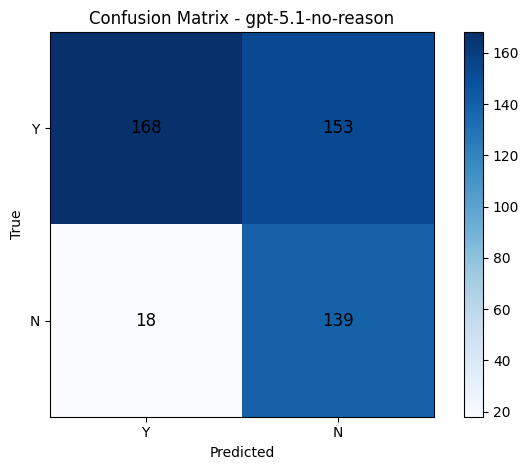

gpt-5.1: matched 478 rows


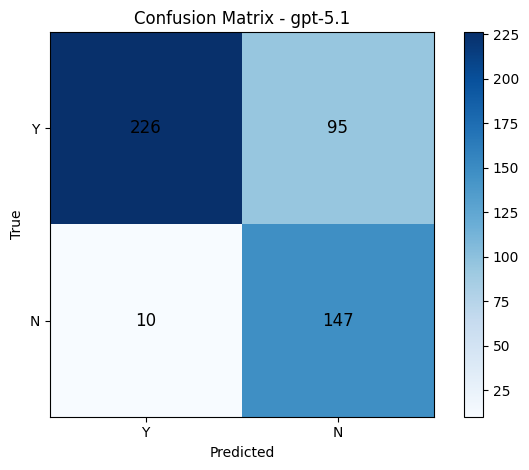

gpt-4o-mini: matched 478 rows


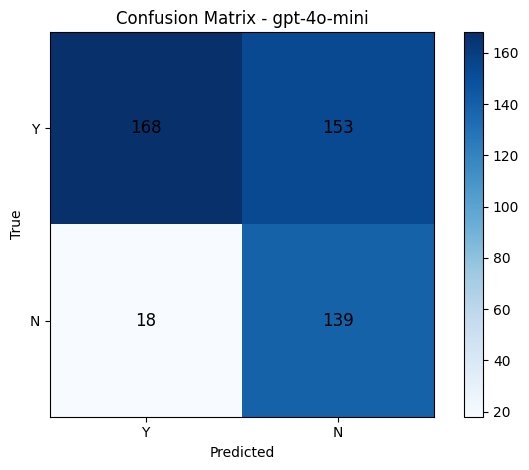


Metrics vs ground truth (Y is positive, plus N and macro):
       model  n_eval  accuracy  precY  recY   f1Y  precN  recN   f1N  macro_prec  macro_rec  macro_f1  TP  FP  TN  FN
gpt-5.1-no-reason     478   0.6423 0.9032 0.5234 0.6627 0.4760 0.8854 0.6192      0.6896     0.7044    0.6409 168  18 139 153
     gpt-5.1     478   0.7803 0.9576 0.7040 0.8115 0.6074 0.9363 0.7368      0.7825     0.8202    0.7742 226  10 147  95
 gpt-4o-mini     478   0.6423 0.9032 0.5234 0.6627 0.4760 0.8854 0.6192      0.6896     0.7044    0.6409 168  18 139 153


In [15]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# ---------------------------------------------------
# CONFIG
# ---------------------------------------------------

TRUE_FILE = "mof_pdf_labels_using gpt5 only YN response 478.xlsx"

# Format: (model_name, prediction_file, prediction_column)
MODELS = [
    ("gpt-5.1-no-reason", "Full_478test_only_gpt-5.1_no_reasoning.xlsx", "Agent_YN"),
    ("gpt-5.1",             "Full_gpt-5.xlsx",                               "Agent_YN"),
    ("gpt-4o-mini",       "Full_gpt-4o-mini.xlsx",                         "Agent_YN"),
]

# ---------------------------------------------------
# DOI Normalization (same as before)
# ---------------------------------------------------
def norm_doi(s):
    if pd.isna(s):
        return None
    st = str(s).strip().lower()
    if not st:
        return None

    st = st.replace("\\", "/").replace("_", "/")
    st = re.sub(r"^(https?://(dx\.)?doi\.org/|doi:)\s*", "", st)
    st = re.sub(r"\.pdf$", "", st)

    m = re.search(r"(10\.\d{4,9}/\S+)", st)
    if m:
        return m.group(1)
    return None

# ---------------------------------------------------
# Load ground truth
# ---------------------------------------------------
df_true = pd.read_excel(TRUE_FILE)

# Identify DOI / File column
id_col_true = "File" if "File" in df_true.columns else (
    "DOI" if "DOI" in df_true.columns else df_true.columns[0]
)

df_true["doi_norm"] = df_true[id_col_true].apply(norm_doi)
df_true["TrueLabel"] = df_true["Agent_YN"].astype(str).str.upper().str.strip()
df_true = df_true[df_true["doi_norm"].notna()]

print(f"Loaded ground truth: {len(df_true)} rows after DOI normalization")

# ---------------------------------------------------
# Metric helpers
# ---------------------------------------------------
def safe_div(n, d):
    return n / d if d != 0 else 0.0

def compute_metrics(y_true, y_pred):
    y_true = y_true.astype(str).str.upper().str.strip()
    y_pred = y_pred.astype(str).str.upper().str.strip()

    # Confusion for Y positive
    TP = int(((y_true == "Y") & (y_pred == "Y")).sum())
    FN = int(((y_true == "Y") & (y_pred == "N")).sum())
    FP = int(((y_true == "N") & (y_pred == "Y")).sum())
    TN = int(((y_true == "N") & (y_pred == "N")).sum())

    total = TP + TN + FP + FN

    # Y positive
    acc       = safe_div(TP + TN, total)
    prec_Y    = safe_div(TP, TP + FP)
    rec_Y     = safe_div(TP, TP + FN)
    f1_Y      = safe_div(2 * prec_Y * rec_Y, prec_Y + rec_Y)

    # N positive (swap roles)
    prec_N    = safe_div(TN, TN + FN)
    rec_N     = safe_div(TN, TN + FP)
    f1_N      = safe_div(2 * prec_N * rec_N, prec_N + rec_N)

    # Macro average over Y and N
    macro_prec = (prec_Y + prec_N) / 2.0
    macro_rec  = (rec_Y + rec_N) / 2.0
    macro_f1   = (f1_Y + f1_N) / 2.0

    return {
        "n_eval": total,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "accuracy": acc,
        "precision_Y": prec_Y,
        "recall_Y": rec_Y,
        "f1_Y": f1_Y,
        "precision_N": prec_N,
        "recall_N": rec_N,
        "f1_N": f1_N,
        "macro_precision": macro_prec,
        "macro_recall": macro_rec,
        "macro_f1": macro_f1,
    }

def plot_confusion_matrix(TP, FN, FP, TN, model_name):
    cm = [[TP, FN],
          [FP, TN]]

    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap="Blues")

    ax.set_title(f"Confusion Matrix - {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Y", "N"])
    ax.set_yticklabels(["Y", "N"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i][j], ha="center", va="center", fontsize=12)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------
# Evaluate each model
# ---------------------------------------------------
results = []

for model_name, pred_file, pred_col in MODELS:

    df_pred = pd.read_excel(pred_file)

    # identify DOI column in prediction file
    id_col_pred = "File" if "File" in df_pred.columns else (
        "DOI" if "DOI" in df_pred.columns else df_pred.columns[0]
    )

    df_pred["doi_norm"] = df_pred[id_col_pred].apply(norm_doi)
    df_pred["PredLabel"] = df_pred[pred_col].astype(str).str.upper().str.strip()

    # merge on doi_norm
    merged = df_true.merge(
        df_pred[["doi_norm", "PredLabel"]],
        on="doi_norm",
        how="inner",
        suffixes=("_true", "_pred")
    )

    if merged.empty:
        print(f"\nWARNING: No matched rows for {model_name}. Skipping.")
        continue

    metrics = compute_metrics(merged["TrueLabel"], merged["PredLabel"])
    metrics["model"] = model_name
    results.append(metrics)

    print(f"{model_name}: matched {metrics['n_eval']} rows")

    # plot confusion matrix for this model
    plot_confusion_matrix(
        metrics["TP"], metrics["FN"], metrics["FP"], metrics["TN"], model_name
    )

# ---------------------------------------------------
# Pretty print results
# ---------------------------------------------------
print("\nMetrics vs ground truth (Y is positive, plus N and macro):")
header = (
    "       model  n_eval  accuracy  "
    "precY  recY   f1Y  precN  recN   f1N  "
    "macro_prec  macro_rec  macro_f1  TP  FP  TN  FN"
)
print(header)

for r in results:
    print(
        f"{r['model']:>12} "
        f"{r['n_eval']:7d} "
        f"{r['accuracy']:8.4f} "
        f"{r['precision_Y']:6.4f} "
        f"{r['recall_Y']:5.4f} "
        f"{r['f1_Y']:6.4f} "
        f"{r['precision_N']:6.4f} "
        f"{r['recall_N']:5.4f} "
        f"{r['f1_N']:6.4f} "
        f"{r['macro_precision']:11.4f} "
        f"{r['macro_recall']:10.4f} "
        f"{r['macro_f1']:9.4f} "
        f"{r['TP']:3d} "
        f"{r['FP']:3d} "
        f"{r['TN']:3d} "
        f"{r['FN']:3d}"
    )
